In [ ]:
!pip install xgboost shap pyreadstat openpyxl ipywidgets -q
from google.colab import output
output.enable_custom_widget_manager()
print("✅ All libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.1 MB/s eta 0:00:00
✅ All libraries installed


In [ ]:
from google.colab import files
print("Upload P_PFAS.xlsx and P_KIQ_U.xlsx")
uploaded = files.upload()

Upload P_PFAS.xlsx and P_KIQ_U.xlsx


Saving P_PFAS.xlsx to P_PFAS.xlsx
Saving P_KIQ_U.xlsx to P_KIQ_U.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve)
from xgboost import XGBClassifier
import shap
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("✅ Imports done")

✅ Imports done


In [ ]:
SENTINEL = 5.39760534693403e-79
LOD      = 0.07

# ── Load files
pfas = pd.read_excel('P_PFAS.xlsx')
kiq  = pd.read_excel('P_KIQ_U.xlsx')

# ── PFAS: replace sentinel → impute below-LOD → log-transform
pfas.replace(SENTINEL, np.nan, inplace=True)
pfas_lbx = [c for c in pfas.columns if c.startswith('LBX')]
pfas_clean = pfas[['SEQN'] + pfas_lbx].copy()
for col in pfas_lbx:
    pfas_clean[col] = pfas_clean[col].fillna(LOD / np.sqrt(2))
    pfas_clean[col] = np.log(pfas_clean[col])

# ── KIQ: create binary target
#    KIQ022 = 1 → "told by doctor: weak/failing kidneys"
#    KIQ025 = 1 → "received dialysis in past 12 months"
kiq.replace(SENTINEL, np.nan, inplace=True)
kiq['kidney_failure'] = ((kiq['KIQ022'] == 1) | (kiq['KIQ025'] == 1)).astype(int)

kiq_features = ['SEQN', 'kidney_failure',
                 'KIQ005',  # urinary leakage frequency
                 'KIQ010',  # amount leaked
                 'KIQ042',  # bladder control bother
                 'KIQ044',  # urinary urgency
                 'KIQ046',  # stream strength
                 'KIQ050',  # daytime bathroom trips
                 'KIQ052',  # time to pass urine
                 'KIQ026']  # ever had kidney stones
kiq_clean = kiq[kiq_features].copy()

# ── Merge on SEQN
merged = pfas_clean.merge(kiq_clean, on='SEQN', how='inner')
merged.dropna(subset=['kidney_failure'], inplace=True)

print(f"✅ Total samples      : {len(merged)}")
print(f"✅ Kidney failure     : {merged['kidney_failure'].sum()} ({merged['kidney_failure'].mean()*100:.1f}%)")
print(f"✅ No kidney failure  : {(merged['kidney_failure']==0).sum()}")
print(f"✅ PFAS features      : {len(pfas_lbx)}")

✅ Total samples      : 2848
✅ Kidney failure     : 130 (4.6%)
✅ No kidney failure  : 2718
✅ PFAS features      : 9


In [ ]:
FEATURE_COLS = pfas_lbx + ['KIQ005','KIQ010','KIQ042',
                             'KIQ044','KIQ046','KIQ050','KIQ052','KIQ026']

df_model = merged[FEATURE_COLS + ['kidney_failure']].copy()
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())

X = df_model[FEATURE_COLS]
y = df_model['kidney_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Train size : {X_train.shape}")
print(f"✅ Test size  : {X_test.shape}")
print(f"✅ Positives in train: {y_train.sum()} | test: {y_test.sum()}")

✅ Train size : (2278, 17)
✅ Test size  : (570, 17)
✅ Positives in train: 104 | test: 26


In [ ]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos
print(f"Class imbalance ratio → scale_pos_weight = {scale:.1f}")

xgb_model = XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale,
    eval_metric      = 'auc',
    random_state     = 42
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

print("✅ Model trained successfully!")

Class imbalance ratio → scale_pos_weight = 20.9
✅ Model trained successfully!


ROC-AUC Score : 0.6445

                precision    recall  f1-score   support

    No Failure       0.96      0.87      0.91       544
Kidney Failure       0.09      0.27      0.13        26

      accuracy                           0.84       570
     macro avg       0.52      0.57      0.52       570
  weighted avg       0.92      0.84      0.88       570



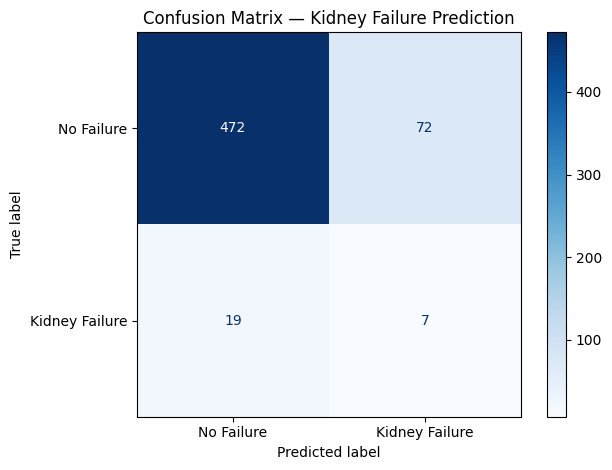

In [ ]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score : {auc:.4f}\n")
print(classification_report(y_test, y_pred,
      target_names=['No Failure', 'Kidney Failure']))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Kidney Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Kidney Failure Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

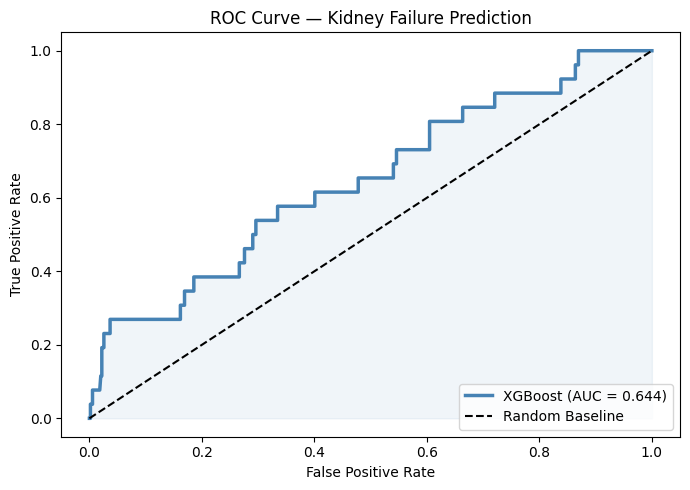

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Kidney Failure Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

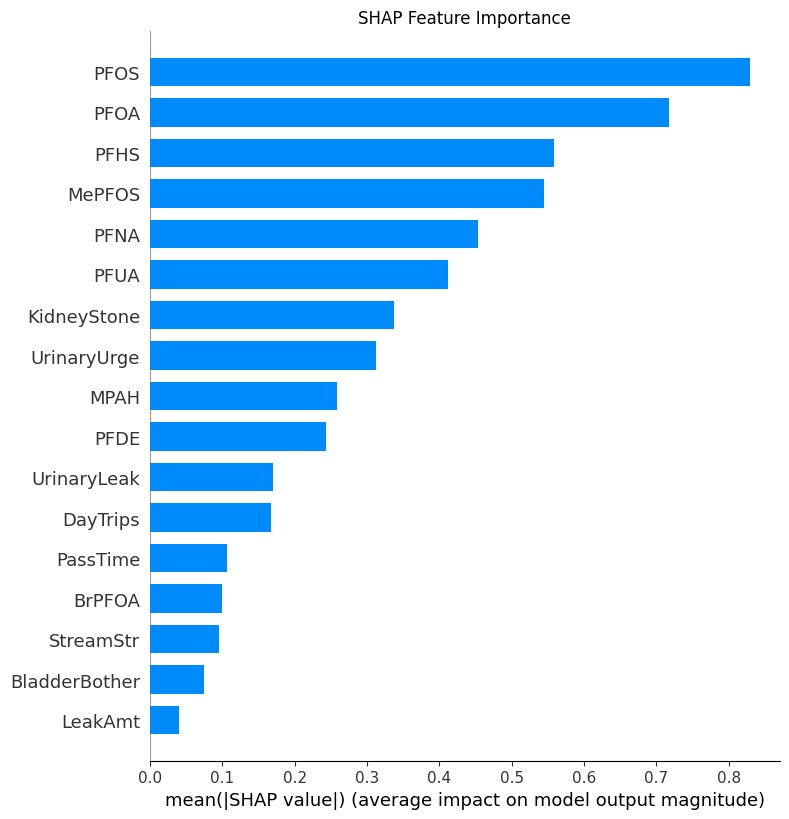

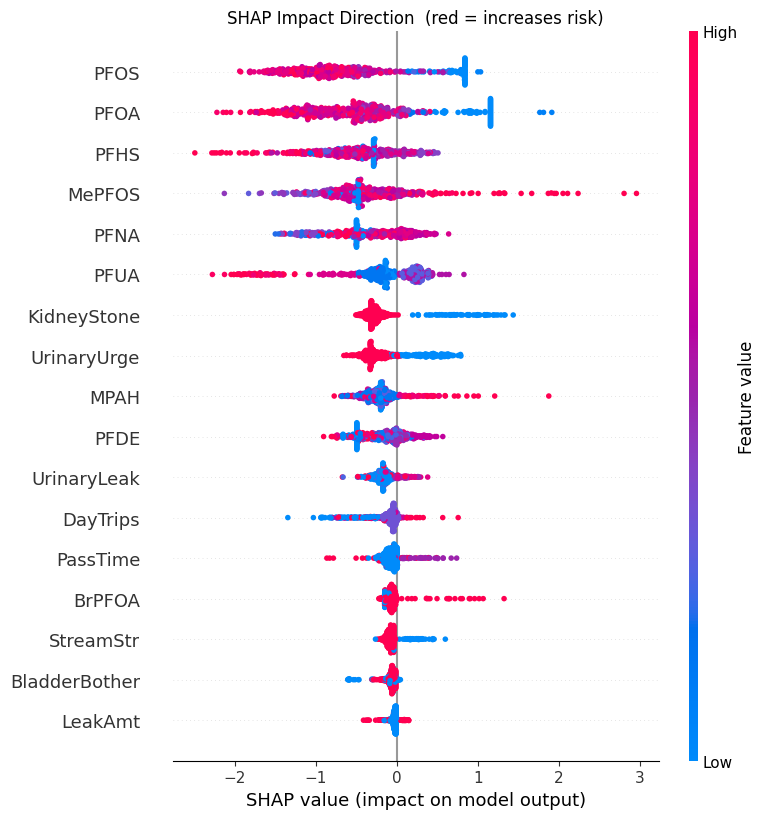

In [ ]:
LABEL_MAP = {
    'LBXPFDE':'PFDE',  'LBXPFHS':'PFHS',  'LBXMPAH':'MPAH',
    'LBXPFNA':'PFNA',  'LBXPFUA':'PFUA',  'LBXNFOA':'PFOA',
    'LBXBFOA':'BrPFOA','LBXNFOS':'PFOS',  'LBXMFOS':'MePFOS',
    'KIQ005':'UrinaryLeak', 'KIQ010':'LeakAmt',  'KIQ042':'BladderBother',
    'KIQ044':'UrinaryUrge', 'KIQ046':'StreamStr', 'KIQ050':'DayTrips',
    'KIQ052':'PassTime',    'KIQ026':'KidneyStone'
}

X_test_named = X_test.rename(columns=LABEL_MAP)

explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test_named)

# Bar chart — overall importance
plt.figure()
shap.summary_plot(shap_vals, X_test_named, plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150)
plt.show()

# Dot plot — direction of effect
plt.figure()
shap.summary_plot(shap_vals, X_test_named, show=False)
plt.title('SHAP Impact Direction  (red = increases risk)')
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150)
plt.show()

In [ ]:
# ── PFAS Inputs
pfas_inputs = {
    'LBXPFDE': widgets.BoundedFloatText(value=0.2,  min=0.07, max=100, step=0.01, description='PFDE (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXPFHS': widgets.BoundedFloatText(value=1.0,  min=0.07, max=100, step=0.01, description='PFHS (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXMPAH': widgets.BoundedFloatText(value=0.1,  min=0.07, max=100, step=0.01, description='MPAH (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXPFNA': widgets.BoundedFloatText(value=0.5,  min=0.07, max=100, step=0.01, description='PFNA (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXPFUA': widgets.BoundedFloatText(value=0.1,  min=0.07, max=100, step=0.01, description='PFUA (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXNFOA': widgets.BoundedFloatText(value=1.5,  min=0.07, max=100, step=0.01, description='PFOA (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXBFOA': widgets.BoundedFloatText(value=0.07, min=0.07, max=100, step=0.01, description='BrPFOA (ng/mL):', style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXNFOS': widgets.BoundedFloatText(value=3.0,  min=0.07, max=200, step=0.01, description='PFOS (ng/mL):',   style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
    'LBXMFOS': widgets.BoundedFloatText(value=1.0,  min=0.07, max=100, step=0.01, description='MePFOS (ng/mL):', style={'description_width':'155px'}, layout=widgets.Layout(width='330px')),
}

# ── Clinical Inputs
kiq_inputs = {
    'KIQ005': widgets.Dropdown(options=[('Never',1),('Less than monthly',2),('Monthly',3),('Weekly',4),('Daily/Almost daily',5)],
        value=1, description='Urinary Leakage:', style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ010': widgets.Dropdown(options=[('N/A or drops',1),('Wet underwear',2),('Wet outer clothes',3)],
        value=1, description='Leakage Amount:',  style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ042': widgets.Dropdown(options=[('Yes — bothers me',1),('No',2)],
        value=2, description='Bladder Bother:',  style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ044': widgets.Dropdown(options=[('Never',1),('Less than monthly',2),('Monthly',3),('Weekly',4),('Daily/Almost daily',5)],
        value=1, description='Urinary Urgency:', style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ046': widgets.Dropdown(options=[('Very strong',1),('Strong',2),('Average',3),('Weak',4),('Very weak',5)],
        value=2, description='Stream Strength:', style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ050': widgets.BoundedIntText(value=6, min=1, max=30,
        description='Daytime Trips:',     style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ052': widgets.Dropdown(options=[('Less than 5 min',1),('5–10 min',2),('More than 10 min',3)],
        value=1, description='Time to Urinate:', style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
    'KIQ026': widgets.Dropdown(options=[('Yes',1),('No',2)],
        value=2, description='Kidney Stones?:',  style={'description_width':'165px'}, layout=widgets.Layout(width='350px')),
}

# ── Patient ID + Buttons + Output
patient_name = widgets.Text(value='', placeholder='e.g. Patient 001',
    description='Patient ID:', style={'description_width':'120px'}, layout=widgets.Layout(width='300px'))
predict_btn  = widgets.Button(description='🔬 Predict Risk', button_style='primary', layout=widgets.Layout(width='200px', height='40px'))
clear_btn    = widgets.Button(description='🔄 Clear Form',   button_style='warning', layout=widgets.Layout(width='160px', height='40px'))
output_area  = widgets.Output()
history_rows = []

# ── Render UI
display(HTML("""
<div style='background:#1a1a2e;padding:16px 24px;border-radius:10px;margin-bottom:14px'>
  <h2 style='color:#e0e0ff;margin:0;font-family:sans-serif'>🩺 Kidney Failure Risk Predictor</h2>
  <p style='color:#a0a0cc;margin:6px 0 0;font-family:sans-serif;font-size:13px'>
    PFAS serum exposure + urological symptoms → XGBoost prediction
  </p>
</div>
"""))

display(HTML("<h4 style='font-family:sans-serif;margin-bottom:4px'>👤 Patient Info</h4>"))
display(patient_name)

display(HTML("<h4 style='font-family:sans-serif;margin:16px 0 4px'>🧪 PFAS Blood Serum Levels (ng/mL)</h4>"))
display(widgets.HBox([
    widgets.VBox(list(pfas_inputs.values())[:5]),
    widgets.VBox(list(pfas_inputs.values())[5:])
]))

display(HTML("<h4 style='font-family:sans-serif;margin:16px 0 4px'>🏥 Urological Symptoms</h4>"))
display(widgets.HBox([
    widgets.VBox(list(kiq_inputs.values())[:4]),
    widgets.VBox(list(kiq_inputs.values())[4:])
]))

display(widgets.HBox([predict_btn, clear_btn]))
display(output_area)

Text(value='', description='Patient ID:', layout=Layout(width='300px'), placeholder='e.g. Patient 001', style=…

Output()

In [ ]:
def on_predict(btn):
    with output_area:
        clear_output()

        # Build feature vector
        raw_pfas = {col: w.value for col, w in pfas_inputs.items()}
        raw_kiq  = {col: w.value for col, w in kiq_inputs.items()}

        # Same log-transform as training
        log_pfas = {col: np.log(max(val, 0.07)) for col, val in raw_pfas.items()}

        all_feats     = {**log_pfas, **raw_kiq}
        feature_order = list(pfas_inputs.keys()) + list(kiq_inputs.keys())
        X_input       = pd.DataFrame([[all_feats[f] for f in feature_order]],
                                      columns=feature_order)

        # Predict
        risk_score = xgb_model.predict_proba(X_input)[0][1]
        risk_pct   = risk_score * 100

        # Risk category
        if risk_score < 0.10:
            cat, color, emoji, advice = "LOW",      "#2ecc71", "🟢", "No immediate concern. Routine monitoring recommended."
        elif risk_score < 0.30:
            cat, color, emoji, advice = "MODERATE", "#f39c12", "🟡", "Some risk factors present. Consider follow-up testing."
        elif risk_score < 0.50:
            cat, color, emoji, advice = "HIGH",     "#e67e22", "🟠", "Elevated risk detected. Clinical evaluation strongly advised."
        else:
            cat, color, emoji, advice = "CRITICAL", "#e74c3c", "🔴", "High probability of kidney failure. Urgent medical review needed."

        pid = patient_name.value or "Unknown"

        # Top 3 PFAS markers
        top_pfas = sorted(raw_pfas.items(), key=lambda x: x[1], reverse=True)[:3]
        name_map = {'LBXPFDE':'PFDE','LBXPFHS':'PFHS','LBXMPAH':'MPAH',
                    'LBXPFNA':'PFNA','LBXPFUA':'PFUA','LBXNFOA':'PFOA',
                    'LBXBFOA':'BrPFOA','LBXNFOS':'PFOS','LBXMFOS':'MePFOS'}
        top_str = ", ".join([f"{name_map[k]}={v:.2f}" for k, v in top_pfas])

        history_rows.append({'Patient ID': pid, 'Risk Score': f"{risk_pct:.1f}%",
                              'Category': cat, 'Top PFAS': top_str})

        # Result card
        display(HTML(f"""
        <div style='border:2px solid {color};border-radius:12px;padding:20px;
                    background:#fafafa;font-family:sans-serif;max-width:500px;margin-top:10px'>
          <h3 style='margin:0 0 10px;color:#222'>{emoji} Patient: <span style='color:#555'>{pid}</span></h3>
          <div style='background:{color};border-radius:8px;padding:14px;text-align:center'>
            <span style='font-size:40px;font-weight:bold;color:white'>{risk_pct:.1f}%</span><br>
            <span style='color:white;font-size:20px;font-weight:bold'>{cat} RISK</span>
          </div>
          <p style='margin:12px 0 4px;color:#333'><b>📋 Advice:</b> {advice}</p>
          <p style='margin:4px 0;color:#666;font-size:13px'><b>Top PFAS markers:</b> {top_str}</p>
          <p style='margin:4px 0;color:#999;font-size:11px'>Model: XGBoost | AUC: {auc:.3f} | Dataset: NHANES 2017–2020</p>
        </div>
        """))

def on_clear(btn):
    with output_area:
        clear_output()
    for w in pfas_inputs.values():
        w.value = w.min
    for w in kiq_inputs.values():
        w.value = w.options[0][1] if hasattr(w, 'options') else w.min
    patient_name.value = ''

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)
print("✅ GUI is ready — fill in the form above and click 🔬 Predict Risk")

✅ GUI is ready — fill in the form above and click 🔬 Predict Risk
